In [2]:
import uproot
import awkward as ak
import argparse
import logging
from tqdm import tqdm
from pathlib import Path
import os

os.chdir('/global/cfs/cdirs/m4474/aneek/particlemind')

from src.datasets.CLDHits import CLDHits


In [3]:
parquet_dir = '/global/cfs/cdirs/m4474/aneek/particlemind/scripts/data/p8_ee_tt_ecm365_parquet'

dataset = CLDHits(parquet_dir, "train", nfiles=10, by_event=True)

#file = parquet_dir + '/reco_p8_ee_tt_ecm365_62283.parquet'

#data = ak.from_parquet(file)

In [6]:
data = next(iter(dataset))
len(data['calo_hit_features'][:,3])

10862

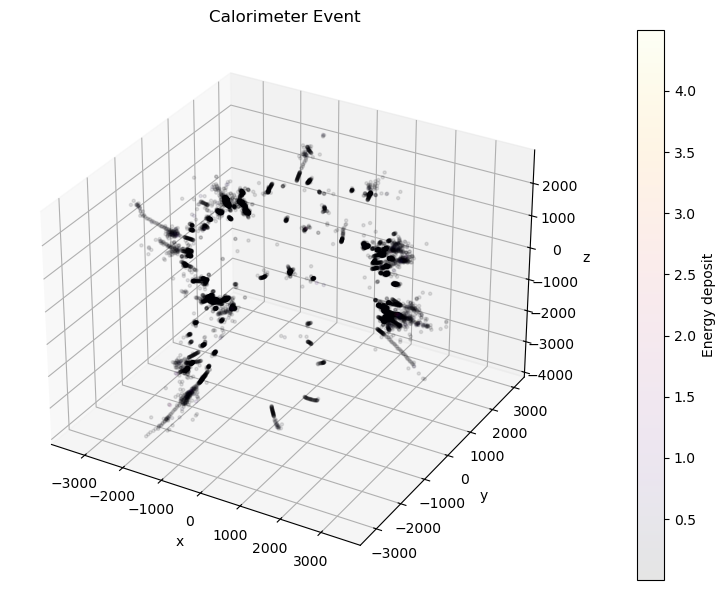

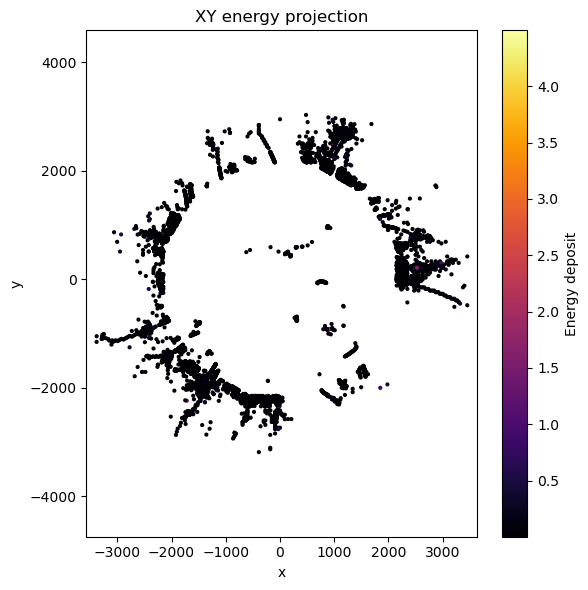

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_event(calo_hit_features, title="Calorimeter Event"):
    """
    calo_hit_features: array of shape (N_hits, 4)
                       columns = [x, y, z, energy]
    """
    x = calo_hit_features[:, 0]
    y = calo_hit_features[:, 1]
    z = calo_hit_features[:, 2]
    energy = calo_hit_features[:, 3]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(
        x, y, z,
        c=energy,
        s=5,                 # marker size
        cmap="inferno",
        alpha=0.1
    )

    cbar = plt.colorbar(sc, ax=ax, pad=0.1)
    cbar.set_label("Energy deposit")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

def plot_xy_energy(calo_hit_features):
    x = calo_hit_features[:, 0]
    y = calo_hit_features[:, 1]
    energy = calo_hit_features[:, 3]

    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, c=energy, s=4, cmap="inferno")
    plt.colorbar(label="Energy deposit")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("XY energy projection")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()



plot_event(data['calo_hit_features'])
plot_xy_energy(data['calo_hit_features'])

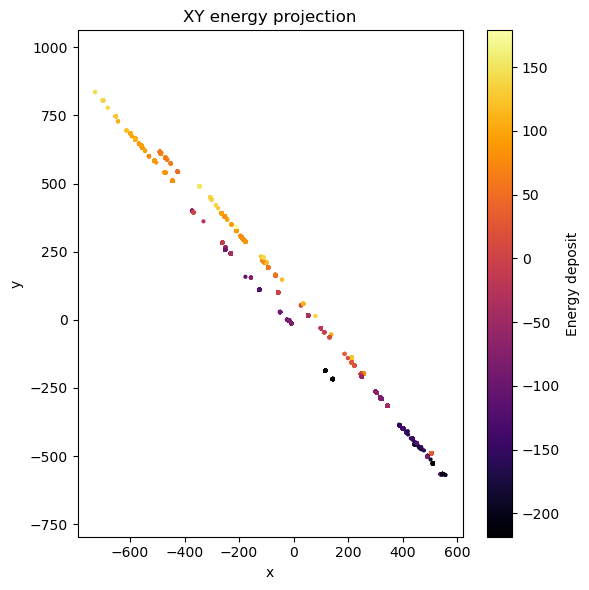

In [7]:
'''

Testing out the model


'''

import os
from argparse import ArgumentParser

from torch.utils.data import DataLoader

from lightning import Trainer, seed_everything
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import WandbLogger, TensorBoardLogger


from src.datasets.CLDHits import CLDHits
from src.datasets.utils import Collater
from src.models.vqvae import VQVAELightning

parser = ArgumentParser()

# PROGRAM ARGS
parser.add_argument("--gpu_id", type=str, default="0")
parser.add_argument("--precision", type=int, default=32, choices=[16, 32])

parser.add_argument("--save_dir", type=str, default="/pscratch/sd/r/rmastand/particlemind/")
parser.add_argument("--name", type=str, default="test")
parser.add_argument("--project", type=str, default="vqvae_training")
parser.add_argument("--logger", type=str, default="wandb", choices=["tensorboard", "wandb"])

# DATA ARGS
parser.add_argument(
    "--data_dir", type=str, default=parquet_dir
)
parser.add_argument("--batch_size", type=int, default=1)
parser.add_argument("--num_files", type=int, default=50)

# TRAINER ARGS
parser.add_argument("--max_epochs", type=int, default=3)
parser.add_argument("--learning_rate", type=float, default=1e-4)
parser.add_argument("--weight_decay", type=float, default=1e-2)

# MODEL args
parser.add_argument("--hidden_dim", type=int, default=128)
parser.add_argument("--latent_dim", type=int, default=4)
parser.add_argument("--num_blocks", type=int, default=3)
parser.add_argument("--num_heads", type=int, default=8)
parser.add_argument("--alpha", type=int, default=5)
parser.add_argument("--num_codes", type=int, default=512)
parser.add_argument("--beta", type=float, default=0.9)
parser.add_argument("--kmeans_init", type=bool, default=True)
parser.add_argument("--affine_lr", type=float, default=0.0)
parser.add_argument("--sync_nu", type=int, default=2)
parser.add_argument("--replace_freq", type=int, default=20)

#args = parser.parse_args()

args, unknown = parser.parse_known_args()


'''
model = VQVAELightning(
        optimizer_kwargs={"lr": args.learning_rate, "weight_decay": args.weight_decay},
        # scheduler = None,
        model_kwargs={
            "input_dim": 4,
            "latent_dim": args.latent_dim,
            "hidden_dim": args.hidden_dim,
            "num_heads": args.num_heads,
            "num_blocks": args.num_blocks,
            "alpha": args.alpha,
            "vq_kwargs": {
                "num_codes": args.num_codes,
                "beta": args.beta,
                "kmeans_init": args.kmeans_init,
                #   "norm": "null",
                # "cb_norm": "null",
                "affine_lr": args.affine_lr,
                "sync_nu": args.sync_nu,
                "replace_freq": args.replace_freq,
                "dim": -1,
            },
        },
        model_type="VQVAENormFormer",
    )
'''

model = VQVAELightning.load_from_checkpoint(
    '/pscratch/sd/a/aneekj02/particlemind/vqvae_training/final_model/test_final.ckpt',
    map_location="cpu"   # or "cpu"
)


loader = DataLoader(dataset, batch_size=1, collate_fn=Collater("all"))

reco, _ = model(next(iter(loader))['calo_hit_features'],next(iter(loader))['calo_hit_mask'])

reco[:,3]

plot_xy_energy(reco.detach().cpu().numpy()[0])

In [10]:
len(next(iter(loader))['calo_hit_features'][:,1])

1

In [58]:
reco.shape

model = VQVAELightning.load_from_checkpoint(
    '/pscratch/sd/a/aneekj02/vqvae_training/best_models/test_val_loss_epoch=00-v2.ckpt',
    map_location="cuda"   # or "cpu"
)

In [8]:
#data.fields
data['calo_hit_features'][0]

<Record {type: [1010, ...], energy: [...], ...} type='{type: var * int64, e...'>

In [9]:
data['calo_hit_features'][0]['energy']

<Array [0.00875, 0.0116, 0.0063, ..., 0.035, 0.0402] type='8166 * float64'>